In [18]:
import torch
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")


PyTorch version: 2.5.1+cu121
CUDA available: False
Device: CPU


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

import gc
gc.collect()
torch.cuda.empty_cache()

In [20]:
class ResNetMLP(nn.Module):
    def __init__(self, num_classes):
        super(ResNetMLP, self).__init__()
        
        # 1. Load a pretrained ResNet (e.g. ResNet18)
        base_model = models.resnet18(pretrained=True)
        
        # 2. Remove the final FC layer -> get features instead
        self.feature_extractor = nn.Sequential(*list(base_model.children())[:-1])
        
        # 3. MLP classifier head
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),   # ResNet18 outputs 512-dim features
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        features = self.feature_extractor(x)   # shape: (batch, 512, 1, 1)
        features = features.view(features.size(0), -1)  # flatten
        out = self.classifier(features)
        return out


Part A — sensitivity scan analysis + tiny models

In [28]:
# Cell 1: imports & env check
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage import filters, feature, transform, io, color
from scipy import fftpack
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import torch, torchvision
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
import time
import json

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


torch: 2.5.1+cu121
cuda available: False


In [29]:
# Cell 2: locate runs & images
BASE = Path("./mumax_files/logs")
LOG_CSV = BASE / "sensitivity_simulation_log.csv"   
ROOT = '/home/santiago/Desktop/Things/grade/mumax3-LTEM-MFM'

# Load the CSV 
df_log = pd.read_csv(LOG_CSV)
df_log.head(10)


,run_id,sample_idx,realization,Dind,Ku1,Aex,alpha,Temp,sigma,mx3_path,ku_map_path,out_dir,returncode,stdout_file,stderr_file,timestamp_start,timestamp_end
0,1,0,0,0.000913,613237.590465,7.412909e-12,0.486974,243.647258,0.095501,mumax_files/logs/run_00001/run_00001.mx3,mumax_files/logs/run_00001/Ku_map.txt,mumax_files/logs/run_00001,1,mumax_files/logs/run_00001/mumax_stdout.txt,mumax_files/logs/run_00001/mumax_stderr.txt,2025-10-05 07:51:56,2025-10-05 07:51:58
1,2,0,1,0.000913,613237.590465,7.412909e-12,0.486974,243.647258,0.095501,mumax_files/logs/run_00002/run_00002.mx3,mumax_files/logs/run_00002/Ku_map.txt,mumax_files/logs/run_00002,1,mumax_files/logs/run_00002/mumax_stdout.txt,mumax_files/logs/run_00002/mumax_stderr.txt,2025-10-05 07:51:58,2025-10-05 07:51:58
2,3,0,2,0.000913,613237.590465,7.412909e-12,0.486974,243.647258,0.095501,mumax_files/logs/run_00003/run_00003.mx3,mumax_files/logs/run_00003/Ku_map.txt,mumax_files/logs/run_00003,1,mumax_files/logs/run_00003/mumax_stdout.txt,mumax_files/logs/run_00003/mumax_stderr.txt,2025-10-05 07:51:58,2025-10-05 07:51:58
3,4,1,0,0.000979,352581.504088,7.740728e-12,0.894504,137.902660,0.175393,mumax_files/logs/run_00004/run_00004.mx3,mumax_files/logs/run_00004/Ku_map.txt,mumax_files/logs/run_00004,1,mumax_files/logs/run_00004/mumax_stdout.txt,mumax_files/logs/run_00004/mumax_stderr.txt,2025-10-05 07:51:58,2025-10-05 07:51:59
4,5,1,1,0.000979,352581.504088,7.740728e-12,0.894504,137.902660,0.175393,mumax_files/logs/run_00005/run_00005.mx3,mumax_files/logs/run_00005/Ku_map.txt,mumax_files/logs/run_00005,1,mumax_files/logs/run_00005/mumax_stdout.txt,mumax_files/logs/run_00005/mumax_stderr.txt,2025-10-05 07:51:59,2025-10-05 07:51:59
5,6,1,2,0.000979,352581.504088,7.740728e-12,0.894504,137.902660,0.175393,mumax_files/logs/run_00006/run_00006.mx3,mumax_files/logs/run_00006/Ku_map.txt,mumax_files/logs/run_00006,1,mumax_files/logs/run_00006/mumax_stdout.txt,mumax_files/logs/run_00006/mumax_stderr.txt,2025-10-05 07:51:59,2025-10-05 07:51:59
6,7,2,0,0.000861,389472.432081,1.240849e-11,0.282272,275.181949,0.193475,mumax_files/logs/run_00007/run_00007.mx3,mumax_files/logs/run_00007/Ku_map.txt,mumax_files/logs/run_00007,1,mumax_files/logs/run_00007/mumax_stdout.txt,mumax_files/logs/run_00007/mumax_stderr.txt,2025-10-05 07:51:59,2025-10-05 07:51:59
7,8,2,1,0.000861,389472.432081,1.240849e-11,0.282272,275.181949,0.193475,mumax_files/logs/run_00008/run_00008.mx3,mumax_files/logs/run_00008/Ku_map.txt,mumax_files/logs/run_00008,1,mumax_files/logs/run_00008/mumax_stdout.txt,mumax_files/logs/run_00008/mumax_stderr.txt,2025-10-05 07:51:59,2025-10-05 07:51:59
8,9,2,2,0.000861,389472.432081,1.240849e-11,0.282272,275.181949,0.193475,mumax_files/logs/run_00009/run_00009.mx3,mumax_files/logs/run_00009/Ku_map.txt,mumax_files/logs/run_00009,1,mumax_files/logs/run_00009/mumax_stdout.txt,mumax_files/logs/run_00009/mumax_stderr.txt,2025-10-05 07:51:59,2025-10-05 07:51:59
9,10,3,0,0.001114,498304.615772,1.303172e-11,0.753545,109.902327,0.026429,mumax_files/logs/run_00010/run_00010.mx3,mumax_files/logs/run_00010/Ku_map.txt,mumax_files/logs/run_00010,1,mumax_files/logs/run_00010/mumax_stdout.txt,mumax_files/logs/run_00010/mumax_stderr.txt,2025-10-05 07:51:59,2025-10-05 07:52:00


In [ ]:
import subprocess

# Convert .ovf mumax output to numpy array
def load_mumax_output(run_dir, in_ovf="final"):
    
    # List directories in root
    run_dir = Path(run_dir)
    directories = [str(d) for d in run_dir.iterdir() if d.is_dir()]
    #print("Directories in run folder:", sorted(directories))

    for i,d in enumerate(sorted(directories), start=1):
        print("Processing directory:", d)
        route = str(ROOT + '/' + d + f'/{in_ovf}.ovf')
        subprocess.run(['mumax3-convert', '-numpy', route])    
        
load_mumax_output(BASE)

In [31]:
# Cell 3: helper to load an image for a run directory
def load_image_from_run(run_dir: Path):
    """
    Tries to load in order:
      1) final_mz.npy or m_z.npy or image.npy inside run_dir
      2) final.ovf -> requires a converter (not implemented here)
      3) final.png / final.tif
    Returns float32 array (H,W) normalized between 0..1.
    """
        
    ## check png/tif
    #for ext in ("png","tif","tiff","jpg","jpeg"):
    #    p = run_dir / f"final.{ext}"
    #    if p.exists():
    #        im = io.imread(p)
    #        if im.ndim==3:
    #            im = color.rgb2gray(im)
    #        im = im.astype(np.float32)
    #        im = (im - im.min()) / (im.ptp() + 1e-12)
    #        return im
    
    # Try to find any npy in the folder
    for p in run_dir.glob("final.npy"):
        #print(p)
        arr = np.load(p)
        print("Loaded", p, "shape:", arr.shape)
            
    # fallback: return None
    return arr

# Quick test: load first 10
sample_runs = [Path(r) for r in df_log["out_dir"].values[:]]
#print(sample_runs)
for r in sample_runs:
    arr = load_image_from_run(ROOT / r)   # arr shape (3,nz,ny,nx)
    #print(arr)
   # print(r, "->", None if arr is None else arr.shape)


Loaded /home/santiago/Desktop/Things/grade/mumax3-LTEM-MFM/mumax_files/logs/run_00001/final.npy shape: (3, 1, 256, 256)
Loaded /home/santiago/Desktop/Things/grade/mumax3-LTEM-MFM/mumax_files/logs/run_00002/final.npy shape: (3, 1, 256, 256)
Loaded /home/santiago/Desktop/Things/grade/mumax3-LTEM-MFM/mumax_files/logs/run_00003/final.npy shape: (3, 1, 256, 256)
Loaded /home/santiago/Desktop/Things/grade/mumax3-LTEM-MFM/mumax_files/logs/run_00004/final.npy shape: (3, 1, 256, 256)
Loaded /home/santiago/Desktop/Things/grade/mumax3-LTEM-MFM/mumax_files/logs/run_00005/final.npy shape: (3, 1, 256, 256)
Loaded /home/santiago/Desktop/Things/grade/mumax3-LTEM-MFM/mumax_files/logs/run_00006/final.npy shape: (3, 1, 256, 256)
Loaded /home/santiago/Desktop/Things/grade/mumax3-LTEM-MFM/mumax_files/logs/run_00007/final.npy shape: (3, 1, 256, 256)
Loaded /home/santiago/Desktop/Things/grade/mumax3-LTEM-MFM/mumax_files/logs/run_00008/final.npy shape: (3, 1, 256, 256)
Loaded /home/santiago/Desktop/Things/gra

In [51]:
# Cell 4: build dataset arrays (images + target params)
images = []
targets = []
meta = []

for idx, row in df_log.iterrows():

    run_dir = Path(row["out_dir"])
    arr = load_image_from_run(ROOT / run_dir)
    if arr is None:
        print("Warning: could not load image for", run_dir)
        # skip if image not found
        continue

    # Robustly resize to (3, 256, 256)
    arr = np.asarray(arr)
    
    # Step 1: Ensure input array is consistently shaped to (C, H, W)
    # This handles various possible raw shapes like (C, 1, H, W) or (H, W)
    if arr.ndim == 4 and arr.shape[1] == 1: # Handles (C, 1, H, W)
        arr_c = np.squeeze(arr, axis=1)
    elif arr.ndim == 2: # Handles (H, W) by creating 3 identical channels
        arr_c = np.stack([arr, arr, arr], axis=0)
    elif arr.ndim == 3: # Assumes (C, H, W)
        arr_c = arr
    else:
        print(f"Warning: Skipping image with unhandled shape {arr.shape} for {run_dir}")
        continue

    # Step 2: Resize each channel individually to (256, 256)
    target_h, target_w = 256, 256
    img_channels = []
    # Ensure we only process 3 channels if more are present
    num_channels = min(arr_c.shape[0], 3)
    for c in range(num_channels):
        ch_resized = transform.resize(
            arr_c[c],
            (target_h, target_w),
            order=1,
            preserve_range=True,
            anti_aliasing=True
        )
        img_channels.append(ch_resized)
    
    # If original image had fewer than 3 channels (e.g., 1), duplicate to get 3
    while len(img_channels) < 3:
        img_channels.append(img_channels[0].copy())

    img256 = np.stack(img_channels, axis=0).astype(np.float32) # Shape: (3, 256, 256)
    images.append(img256)

    # choose target(s) 
    # We'll predict Dind and sigma if available; else predict Dind only
    D = float(row.get("Dind", np.nan))
    sigma = float(row.get("sigma", row.get("sigma_rel", np.nan)))
    ku1 = float(row.get("Ku1", row.get("sigma_rel", np.nan)))
    Aex = float(row.get("Aex", row.get("sigma_rel", np.nan)))
    alpha = float(row.get("alpha", row.get("sigma_rel", np.nan)))
    temp = float(row.get("Temp", row.get("sigma_rel", np.nan)))


# Dind	Ku1	Aex	alpha	Temp	sigma
    targets.append([D, sigma, ku1,Aex,alpha,temp])
    meta.append(dict(run_dir=str(run_dir), **row.to_dict()))

images = np.stack(images)  # Final shape: (N, 3, 256, 256)
targets = np.array(targets, dtype=np.float32)  # N, 2

print("Loaded images:", images.shape, "targets:", targets.shape)
#print(targets)


Loaded /home/santiago/Desktop/Things/grade/mumax3-LTEM-MFM/mumax_files/logs/run_00001/final.npy shape: (3, 1, 256, 256)
Loaded /home/santiago/Desktop/Things/grade/mumax3-LTEM-MFM/mumax_files/logs/run_00002/final.npy shape: (3, 1, 256, 256)
Loaded /home/santiago/Desktop/Things/grade/mumax3-LTEM-MFM/mumax_files/logs/run_00003/final.npy shape: (3, 1, 256, 256)
Loaded /home/santiago/Desktop/Things/grade/mumax3-LTEM-MFM/mumax_files/logs/run_00004/final.npy shape: (3, 1, 256, 256)
Loaded /home/santiago/Desktop/Things/grade/mumax3-LTEM-MFM/mumax_files/logs/run_00005/final.npy shape: (3, 1, 256, 256)
Loaded /home/santiago/Desktop/Things/grade/mumax3-LTEM-MFM/mumax_files/logs/run_00006/final.npy shape: (3, 1, 256, 256)
Loaded /home/santiago/Desktop/Things/grade/mumax3-LTEM-MFM/mumax_files/logs/run_00007/final.npy shape: (3, 1, 256, 256)
Loaded /home/santiago/Desktop/Things/grade/mumax3-LTEM-MFM/mumax_files/logs/run_00008/final.npy shape: (3, 1, 256, 256)
Loaded /home/santiago/Desktop/Things/gra

<Axes: >

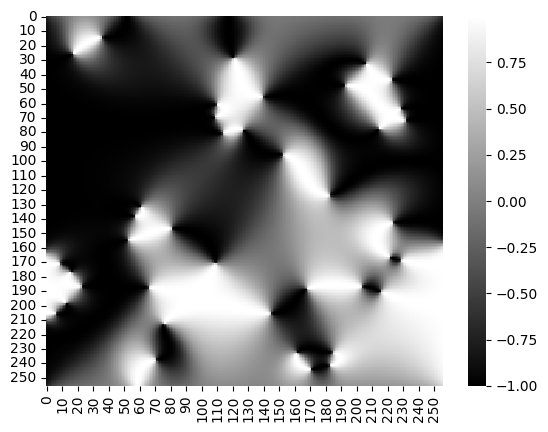

In [33]:
import seaborn as sns
sns.heatmap(images[200,1], cmap='gray')
#sns.heatmap(transform.resize(images[20], (3,128,128), order=1, preserve_range=True, anti_aliasing=True)[2,0])

In [34]:
# Cell 5: compute simple image features for each image
def compute_features(img, channel='mz', collapse_mode='mean'):
    """
    Compute features from an image-like input.
    - img: array-like. Accepts 2D or higher (will collapse leading axes).
    - channel: if img has 3 channels and you want the mz component, use 'mz'.
               otherwise use 'mean' to collapse channels by mean.
    - collapse_mode: 'mean'|'max'|'select'  (select uses channel choice)
    """
    import numpy as np
    from skimage import filters
    from scipy import fftpack

    arr = np.asarray(img)

    # Reduce to a single 2D image (H,W)
    if arr.ndim == 2:
        im2 = arr
    else:
        # If shape like (3,1,H,W) -> squeeze singleton dims first
        arr_s = np.squeeze(arr)
        if arr_s.ndim == 2:
            im2 = arr_s
        elif arr_s.ndim == 3:
            # arr_s could be (3,H,W) or (T,H,W) etc.
            if arr_s.shape[0] == 3 and collapse_mode == 'select' and channel == 'mz':
                im2 = arr_s[2]         # choose mz channel
            elif collapse_mode == 'mean':
                im2 = arr_s.mean(axis=0)
            elif collapse_mode == 'max':
                im2 = arr_s.max(axis=0)
            else:
                # default to mean
                im2 = arr_s.mean(axis=0)
        else:
            # collapse any extra leading dims by mean -> shape (H,W)
            lead_axes = tuple(range(arr_s.ndim - 2))
            im2 = arr_s.mean(axis=lead_axes)

    # ensure float and non-degenerate range
    im2 = im2.astype(np.float32)
    ptp = np.ptp(im2)#im2.ptp()
    if ptp <= 0:
        # constant image: avoid division by zero
        im2 = np.zeros_like(im2, dtype=np.float32)
    else:
        im2 = (im2 - im2.min()) / (ptp + 1e-12)

    feats = {}
    feats["mean"] = float(np.mean(im2))
    feats["std"]  = float(np.std(im2))

    # Sobel edges
    edges = filters.sobel(im2)
    feats["edge_mean"] = float(edges.mean())
    feats["edge_std"]  = float(edges.std())
    feats["edge_frac"] = float((edges > np.percentile(edges, 75)).sum() / edges.size)

    # Otsu segmentation
    try:
        from skimage import filters as skf
        th = skf.threshold_otsu(im2)
        mask = im2 > th
        feats["domain_fraction"] = float(mask.mean())
    except Exception:
        feats["domain_fraction"] = float(0.0)

    # FFT radial power
    F = fftpack.fftshift(fftpack.fft2(im2 - im2.mean()))
    P = np.abs(F) ** 2
    cy, cx = np.array(P.shape) // 2
    y, x = np.indices(P.shape)
    r = np.sqrt((x - cx)**2 + (y - cy)**2).astype(np.int32)
    rmax = min(cx, cy)
    radial = np.bincount(r.ravel(), weights=P.ravel())[:rmax]
    denom = (np.bincount(r.ravel())[:rmax] + 1e-12)
    radial = radial / denom
    if radial.size > 1:
        peak_r = float(np.argmax(radial[1:]) + 1)
    else:
        peak_r = 0.0
    feats["fft_peak_r"] = peak_r
    feats["fft_power_mean"] = float(radial.mean() if radial.size else 0.0)

    return feats

feat_list = [compute_features(im) for im in images]
df_feats = pd.DataFrame(feat_list)
df_meta = pd.DataFrame(meta)
df_all = pd.concat([df_meta.reset_index(drop=True), df_feats.reset_index(drop=True)], axis=1)
df_all[["mean","std","edge_mean","domain_fraction","fft_peak_r"]].sample(10)


,mean,std,edge_mean,domain_fraction,fft_peak_r
243,0.568991,0.284385,0.013791,0.622803,1.0
46,0.594926,0.277012,0.010109,0.624573,1.0
97,0.521791,0.273911,0.010898,0.548172,1.0
9,0.466265,0.261819,0.010632,0.461441,1.0
154,0.545133,0.298351,0.017224,0.550797,1.0
29,0.465929,0.322811,0.006851,0.506790,1.0
201,0.568799,0.272370,0.010613,0.584290,1.0
155,0.545133,0.298351,0.017224,0.550797,1.0
58,0.383969,0.279101,0.007634,0.348389,1.0
122,0.480097,0.287694,0.014105,0.443039,1.0


In [35]:
# Cell 6: quick correlation & RandomForest feature importance
# target: D (index 0); if sigma is NaN you can drop that column
y_D = targets[:,0]
X = df_feats.fillna(0).values

X_train, X_test, y_train, y_test = train_test_split(X, y_D, test_size=0.2, random_state=42)
rf = RandomForestRegressor(n_estimators=200, random_state=0)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print("RF Dind mse:", mean_squared_error(y_test, y_pred), "r2:", r2_score(y_test,y_pred))

# feature importances
feat_names = list(df_feats.columns)
importances = rf.feature_importances_
for n, imp in sorted(zip(feat_names, importances), key=lambda x:-x[1]):
    print(n, round(imp,4))


RF Dind mse: 1.1675537712323947e-08 r2: 0.9322053759308635
mean 0.3206
std 0.2462
domain_fraction 0.169
fft_power_mean 0.1023
edge_mean 0.1006
edge_std 0.0613
edge_frac 0.0
fft_peak_r 0.0


In [ ]:
# Cell 7: Tiny CNN baseline (PyTorch) - regression of D only
# Dataset wrapper
class LTEMDataset(Dataset):
    def __init__(self, images, targets, transform=None):
        self.images = images
        self.targets = targets
        self.transform = transform
    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
        img = self.images[idx]
        # The image is already (3, 256, 256), so just convert to tensor
        x = torch.from_numpy(img).float()
        # Basic normalization
        x = (x - x.mean()) / (x.std() + 1e-6)
        y = torch.tensor(self.targets[idx,0]).float()  # Dind target
        
        # One-time sanity check for the first item
        if idx == 0:
            print(f"Sanity Check: Shape of a single data tensor (x): {x.shape}")
            if torch.isnan(x).any() or torch.isinf(x).any():
                print("Warning: NaN or Inf found in data tensor!")
        
        return x, y

# train/val split
train_idx, val_idx = train_test_split(np.arange(len(images)), test_size=0.2, random_state=0)
train_ds = LTEMDataset(images[train_idx], targets[train_idx])
val_ds = LTEMDataset(images[val_idx], targets[val_idx])

# --- FIX 4: Set num_workers=0 for debugging ---
# This forces data loading to happen in the main process, which can give clearer
# error messages and avoids multiprocessing issues with CUDA.
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=0, pin_memory=True)

# --- FIX 2: Update TinyCNN for 3-channel, 256x256 input ---
class TinyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            # Start with 3 input channels for our (3, 256, 256) image
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 256 -> 128
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 128 -> 64
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 64 -> 32
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2), # 32 -> 16
            nn.AdaptiveAvgPool2d(1) # Pool to 1x1
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self,x):
        return self.fc(self.conv(x)).squeeze(-1)

model = TinyCNN().to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.SmoothL1Loss()   # Huber-like

# --- FIX 3: Add memory clearing to training loop ---
# training loop (small)
def train_one_epoch(model, loader, opt, crit, device):
    model.train()
    tot_loss = 0.0
    for x,y in loader:
        # Move data to GPU
        x = x.to(device); y = y.to(device)
        
        # Forward pass
        out = model(x)
        loss = crit(out, y)
        
        # Backward pass and optimization
        opt.zero_grad(set_to_none=True) # More efficient zeroing
        loss.backward()
        opt.step()
        
        tot_loss += loss.item() * x.shape[0]
        
    # Clear cache after an epoch
    torch.cuda.empty_cache()
    return tot_loss / len(loader.dataset)

def eval_model(model, loader, crit, device):
    model.eval()
    tot_loss = 0.0
    preds, trues = [], []
    with torch.no_grad():
        for x,y in loader:
            x = x.to(device); y = y.to(device)
            out = model(x)
            loss = crit(out, y)
            tot_loss += loss.item() * x.shape[0]
            preds.append(out.cpu().numpy())
            trues.append(y.cpu().numpy())
    preds = np.concatenate(preds)
    trues = np.concatenate(trues)
    return tot_loss/len(loader.dataset), preds, trues

# run a few epochs (since dataset small)
n_epochs = 40
best_val = 1e9

loss = []
val = []

for epoch in range(1, n_epochs+1):
    t0 = time.time()
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss, preds, trues = eval_model(model, val_loader, criterion, DEVICE)

    loss.append(train_loss)
    val.append(val_loss)
    
    t1 = time.time()
    if val_loss < best_val:
        best_val = val_loss
        # Save model state
        torch.save(model.state_dict(), "./tinycnn_best.pth")
    if epoch % 5 == 0 or epoch==1:
        print(f"Epoch {epoch}/{n_epochs} train_loss={train_loss:.4e} val_loss={val_loss:.4e} time={t1-t0:.1f}s")

# final metrics
mse = mean_squared_error(trues, preds)
print("Final val mse:", mse, "rmse:", np.sqrt(mse)) 



🔹 Training for parameter: Dind


IndexError: index 22 is out of bounds for dimension 0 with size 14

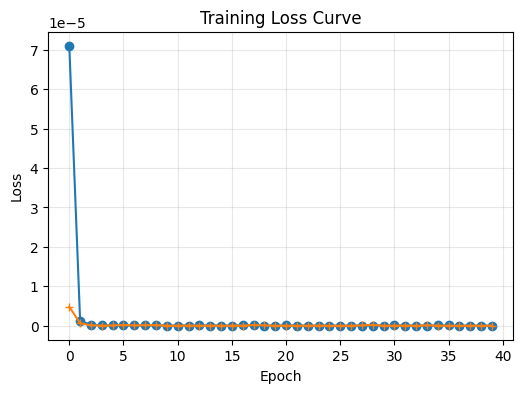

In [42]:
plt.figure(figsize=(6,4))
plt.plot(loss, marker='o')
plt.plot(val, marker='+')
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Get predictions

X_tensor, y = images[train_idx], targets[train_idx]
with torch.no_grad():
    preds = model(X_tensor.to(device)).cpu().numpy()

errors = np.abs(preds - y)
mean_errors = errors.mean(axis=0)

plt.bar(range(len(mean_errors)), mean_errors)
plt.xlabel("Parameter index")
plt.ylabel("Mean Absolute Error")
plt.title("Prediction error per magnetic parameter")
plt.show()

Part B — Tentative complete CNN architectures and training recipe

B1 — CNN mirroring the paper (structure & PyTorch class)

In [ ]:
import torch.nn as nn

class PaperCNN(nn.Module):
    def __init__(self, out_dim=1, in_channels=1):
        super().__init__()
        # conv layers with specified filter counts
        filters = [64,64,40,36,32,28,24,20,16,16]
        layers = []
        C = in_channels
        for i, f in enumerate(filters):
            stride = 1 if i < 6 else 2   # first 6 stride=1, last 4 stride=2
            layers.append(nn.Conv2d(C, f, kernel_size=3, stride=stride, padding=1, bias=False))
            layers.append(nn.BatchNorm2d(f))
            layers.append(nn.ReLU(inplace=True))
            C = f
        self.conv = nn.Sequential(*layers)
        # after convs, spatial size reduced. let's adaptively pool to flatten
        self.pool = nn.AdaptiveAvgPool2d((1,1))
        # FC head: paper uses FC1 with 10 units then final output; we add a hidden layer
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(filters[-1], 64),
            nn.ReLU(),
            nn.Linear(64, out_dim)
        )
    def forward(self, x):
        x = self.conv(x)
        x = self.pool(x)
        x = self.fc(x)
        return x.squeeze(-1) if x.shape[-1]==1 else x


B2 — Modern alternative: ResNet18 backbone + small head

In [11]:
from torchvision.models import resnet18, ResNet18_Weights

class ResNetRegressor(nn.Module):
    def __init__(self, out_dim=1, use_pretrained=True, in_channels=3):
        super().__init__()
        weights = ResNet18_Weights.DEFAULT if use_pretrained else None
        res = resnet18(weights=weights)

        if in_channels != 3:
            w = res.conv1.weight.data
            res.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
            res.conv1.weight.data = w.mean(dim=1, keepdim=True).repeat(1, in_channels, 1, 1)

        res.fc = nn.Sequential(
            nn.Linear(res.fc.in_features, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, out_dim)
        )

        self.model = res

    def forward(self, x):
        return self.model(x)


In [12]:
#print(images.shape)
#images = images.squeeze(2)  # Now shape becomes (270, 3, 256, 256)
#print(images.shape)

In [48]:
import torch
from torch.utils.data import TensorDataset, DataLoader

X = images          # shape (270, 3, 256, 256)
y = targets        # shape (270, 6)


X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

dataset = TensorDataset(X_tensor, y_tensor)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResNetRegressor(out_dim=6, use_pretrained=True, in_channels=3).to(device)


criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

epochs = 10
losses = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for imgs, targets in loader:
        imgs, targets = imgs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())  # Save loss value

        running_loss += loss.item()

    avg_loss = running_loss / len(loader)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.6f}")

print("✅ Training complete!")


Epoch [1/10], Loss: 50098162507.294121
Epoch [2/10], Loss: 50256604220.235291
Epoch [2/10], Loss: 50256604220.235291
Epoch [3/10], Loss: 50130545724.235291
Epoch [3/10], Loss: 50130545724.235291
Epoch [4/10], Loss: 50062924137.411766
Epoch [4/10], Loss: 50062924137.411766
Epoch [5/10], Loss: 50120009366.588234
Epoch [5/10], Loss: 50120009366.588234
Epoch [6/10], Loss: 50058861025.882355
Epoch [6/10], Loss: 50058861025.882355
Epoch [7/10], Loss: 50032094991.058823
Epoch [7/10], Loss: 50032094991.058823
Epoch [8/10], Loss: 50202678332.235291
Epoch [8/10], Loss: 50202678332.235291
Epoch [9/10], Loss: 50161465464.470589
Epoch [9/10], Loss: 50161465464.470589
Epoch [10/10], Loss: 50204391062.588234
✅ Training complete!
Epoch [10/10], Loss: 50204391062.588234
✅ Training complete!


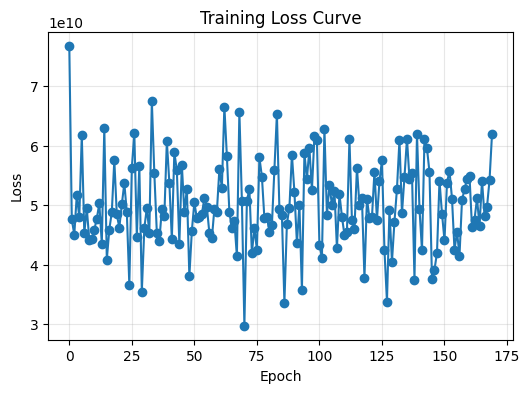

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(losses, marker='o')
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.show()


🔹 Training for parameter: Dind
Epoch 01/30 | train_loss=1.6320e-05 | val_loss=1.6478e-06
Epoch 01/30 | train_loss=1.6320e-05 | val_loss=1.6478e-06
Epoch 05/30 | train_loss=1.0731e-07 | val_loss=7.0458e-08
Epoch 05/30 | train_loss=1.0731e-07 | val_loss=7.0458e-08
Epoch 10/30 | train_loss=7.3302e-08 | val_loss=4.8827e-08
Epoch 10/30 | train_loss=7.3302e-08 | val_loss=4.8827e-08
Epoch 15/30 | train_loss=5.9606e-08 | val_loss=6.1948e-08
Epoch 15/30 | train_loss=5.9606e-08 | val_loss=6.1948e-08
Epoch 20/30 | train_loss=6.4154e-08 | val_loss=4.7215e-08
Epoch 20/30 | train_loss=6.4154e-08 | val_loss=4.7215e-08
Epoch 25/30 | train_loss=5.4991e-08 | val_loss=3.5298e-08
Epoch 25/30 | train_loss=5.4991e-08 | val_loss=3.5298e-08
Epoch 30/30 | train_loss=5.1108e-08 | val_loss=4.2205e-08
Epoch 30/30 | train_loss=5.1108e-08 | val_loss=4.2205e-08


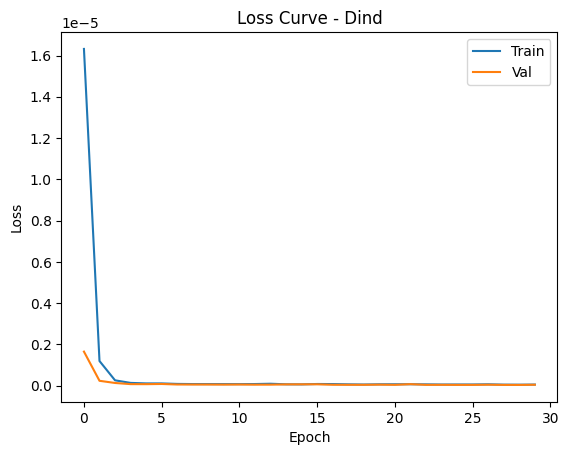

✅ Dind: best val loss=3.3557e-08, RMSE=2.9053e-04

🔹 Training for parameter: sigma

🔹 Training for parameter: sigma
Epoch 01/30 | train_loss=5.3850e-03 | val_loss=2.5027e-03
Epoch 01/30 | train_loss=5.3850e-03 | val_loss=2.5027e-03
Epoch 05/30 | train_loss=1.5565e-03 | val_loss=1.7600e-03
Epoch 05/30 | train_loss=1.5565e-03 | val_loss=1.7600e-03
Epoch 10/30 | train_loss=1.5420e-03 | val_loss=1.9773e-03
Epoch 10/30 | train_loss=1.5420e-03 | val_loss=1.9773e-03
Epoch 15/30 | train_loss=1.5417e-03 | val_loss=1.7667e-03
Epoch 15/30 | train_loss=1.5417e-03 | val_loss=1.7667e-03
Epoch 20/30 | train_loss=1.5716e-03 | val_loss=1.7502e-03
Epoch 20/30 | train_loss=1.5716e-03 | val_loss=1.7502e-03
Epoch 25/30 | train_loss=1.5265e-03 | val_loss=1.7556e-03
Epoch 25/30 | train_loss=1.5265e-03 | val_loss=1.7556e-03
Epoch 30/30 | train_loss=1.5500e-03 | val_loss=1.7203e-03
Epoch 30/30 | train_loss=1.5500e-03 | val_loss=1.7203e-03


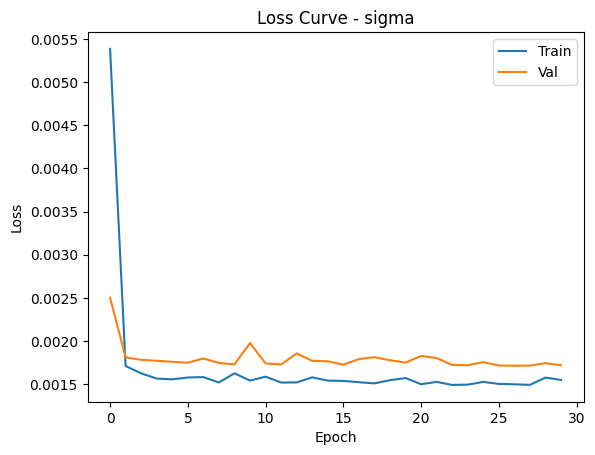

✅ sigma: best val loss=1.7141e-03, RMSE=5.8656e-02

🔹 Training for parameter: Ku1
Epoch 01/30 | train_loss=5.1985e+05 | val_loss=5.4523e+05
Epoch 01/30 | train_loss=5.1985e+05 | val_loss=5.4523e+05
Epoch 05/30 | train_loss=5.1958e+05 | val_loss=5.4472e+05
Epoch 05/30 | train_loss=5.1958e+05 | val_loss=5.4472e+05
Epoch 10/30 | train_loss=4.8475e+05 | val_loss=4.9612e+05
Epoch 10/30 | train_loss=4.8475e+05 | val_loss=4.9612e+05
Epoch 15/30 | train_loss=1.4978e+05 | val_loss=1.5310e+05
Epoch 15/30 | train_loss=1.4978e+05 | val_loss=1.5310e+05
Epoch 20/30 | train_loss=1.4070e+05 | val_loss=1.4634e+05
Epoch 20/30 | train_loss=1.4070e+05 | val_loss=1.4634e+05
Epoch 25/30 | train_loss=1.3965e+05 | val_loss=1.4567e+05
Epoch 25/30 | train_loss=1.3965e+05 | val_loss=1.4567e+05
Epoch 30/30 | train_loss=1.3955e+05 | val_loss=1.4610e+05
Epoch 30/30 | train_loss=1.3955e+05 | val_loss=1.4610e+05


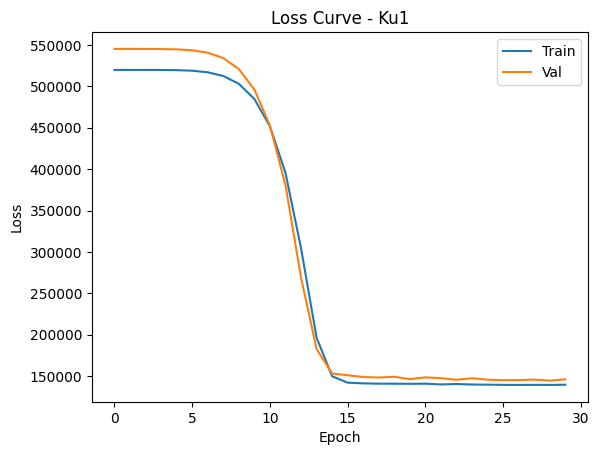

✅ Ku1: best val loss=1.4452e+05, RMSE=1.7134e+05

🔹 Training for parameter: Aex

🔹 Training for parameter: Aex
Epoch 01/30 | train_loss=8.4618e-04 | val_loss=4.2725e-05
Epoch 01/30 | train_loss=8.4618e-04 | val_loss=4.2725e-05
Epoch 05/30 | train_loss=3.2295e-06 | val_loss=2.1290e-06
Epoch 05/30 | train_loss=3.2295e-06 | val_loss=2.1290e-06
Epoch 10/30 | train_loss=5.9434e-07 | val_loss=4.6209e-07
Epoch 10/30 | train_loss=5.9434e-07 | val_loss=4.6209e-07
Epoch 15/30 | train_loss=9.8145e-08 | val_loss=7.5859e-08
Epoch 15/30 | train_loss=9.8145e-08 | val_loss=7.5859e-08
Epoch 20/30 | train_loss=4.0537e-08 | val_loss=2.7987e-08
Epoch 20/30 | train_loss=4.0537e-08 | val_loss=2.7987e-08
Epoch 25/30 | train_loss=2.2843e-08 | val_loss=2.4176e-08
Epoch 25/30 | train_loss=2.2843e-08 | val_loss=2.4176e-08
Epoch 30/30 | train_loss=1.8699e-08 | val_loss=2.4755e-08
Epoch 30/30 | train_loss=1.8699e-08 | val_loss=2.4755e-08


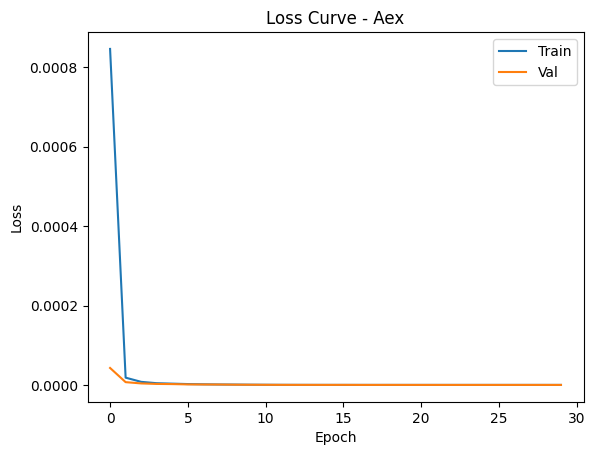

✅ Aex: best val loss=1.5276e-08, RMSE=2.2251e-04

🔹 Training for parameter: alpha
Epoch 01/30 | train_loss=1.6156e-01 | val_loss=8.6141e-02
Epoch 01/30 | train_loss=1.6156e-01 | val_loss=8.6141e-02
Epoch 05/30 | train_loss=3.4682e-02 | val_loss=3.5297e-02
Epoch 05/30 | train_loss=3.4682e-02 | val_loss=3.5297e-02
Epoch 10/30 | train_loss=3.2798e-02 | val_loss=3.4368e-02
Epoch 10/30 | train_loss=3.2798e-02 | val_loss=3.4368e-02
Epoch 15/30 | train_loss=3.2331e-02 | val_loss=3.4444e-02
Epoch 15/30 | train_loss=3.2331e-02 | val_loss=3.4444e-02
Epoch 20/30 | train_loss=3.2234e-02 | val_loss=3.3476e-02
Epoch 20/30 | train_loss=3.2234e-02 | val_loss=3.3476e-02
Epoch 25/30 | train_loss=3.2501e-02 | val_loss=3.3368e-02
Epoch 25/30 | train_loss=3.2501e-02 | val_loss=3.3368e-02
Epoch 30/30 | train_loss=3.1338e-02 | val_loss=3.3185e-02
Epoch 30/30 | train_loss=3.1338e-02 | val_loss=3.3185e-02


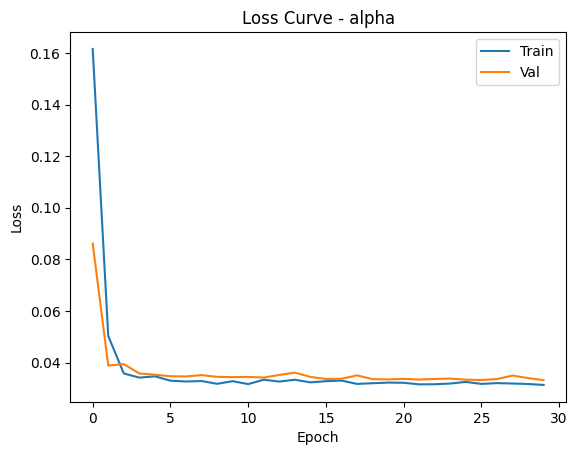

✅ alpha: best val loss=3.3185e-02, RMSE=2.5763e-01

🔹 Training for parameter: Temp
Epoch 01/30 | train_loss=1.4542e+02 | val_loss=1.6480e+02
Epoch 01/30 | train_loss=1.4542e+02 | val_loss=1.6480e+02
Epoch 05/30 | train_loss=8.0608e+01 | val_loss=7.1513e+01
Epoch 05/30 | train_loss=8.0608e+01 | val_loss=7.1513e+01
Epoch 10/30 | train_loss=7.4011e+01 | val_loss=7.3993e+01
Epoch 10/30 | train_loss=7.4011e+01 | val_loss=7.3993e+01
Epoch 15/30 | train_loss=7.3710e+01 | val_loss=7.1629e+01
Epoch 15/30 | train_loss=7.3710e+01 | val_loss=7.1629e+01
Epoch 20/30 | train_loss=7.3538e+01 | val_loss=7.2843e+01
Epoch 20/30 | train_loss=7.3538e+01 | val_loss=7.2843e+01
Epoch 25/30 | train_loss=7.3807e+01 | val_loss=7.1952e+01
Epoch 25/30 | train_loss=7.3807e+01 | val_loss=7.1952e+01
Epoch 30/30 | train_loss=7.3572e+01 | val_loss=7.3209e+01
Epoch 30/30 | train_loss=7.3572e+01 | val_loss=7.3209e+01


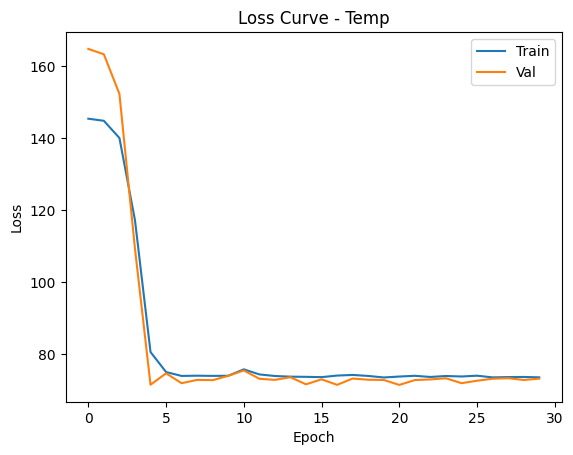

✅ Temp: best val loss=7.1466e+01, RMSE=8.6281e+01


In [ ]:
# ==============================
# 1 Define dataset class (slightly generalized)
# ==============================
class LTEMDataset(Dataset):
    def __init__(self, images, targets, target_idx, transform=None):
        """
        target_idx: list[int] or int — which columns of the target array to use
        """
        self.images = images
        self.targets = targets[:, target_idx] if isinstance(target_idx, (list, tuple)) else targets[:, [target_idx]]
        self.transform = transform
    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
        x = torch.from_numpy(self.images[idx]).float()
        x = (x - x.mean()) / (x.std() + 1e-6)
        y = torch.tensor(self.targets[idx], dtype=torch.float32)
        return x, y

# ==============================
# 2 TinyCNN model (unchanged)
# ==============================
class TinyCNN(nn.Module):
    def __init__(self, out_dim=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d(1)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, out_dim)
        )
    def forward(self, x):
        return self.fc(self.conv(x))

# ==============================
# 3 Training and evaluation utilities
# ==============================
def train_one_epoch(model, loader, opt, crit, device):
    model.train()
    total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        opt.zero_grad(set_to_none=True)
        out = model(x)
        loss = crit(out, y)
        loss.backward()
        opt.step()
        total += loss.item() * x.size(0)
    return total / len(loader.dataset)

def eval_model(model, loader, crit, device):
    model.eval()
    total = 0
    preds, trues = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = crit(out, y)
            total += loss.item() * x.size(0)
            preds.append(out.cpu().numpy())
            trues.append(y.cpu().numpy())
    preds, trues = np.concatenate(preds), np.concatenate(trues)
    return total / len(loader.dataset), preds, trues

# ==============================
# 4 Main training routine per parameter
# ==============================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
param_names = ["Dind", "sigma", "Ku1", "Aex", "alpha", "Temp"]

results = {}

for i, param in enumerate(param_names):
    print(f"\nTraining for parameter: {param}")
    
    # --- Prepare data ---
    train_idx, val_idx = train_test_split(np.arange(len(images)), test_size=0.2, random_state=0)
    train_ds = LTEMDataset(images[train_idx], targets[train_idx], target_idx=i)
    val_ds = LTEMDataset(images[val_idx], targets[val_idx], target_idx=i)
    train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=0)
    
    # --- Initialize model ---
    model = TinyCNN(out_dim=1).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.SmoothL1Loss()

    # --- Train ---
    n_epochs = 30
    best_val = np.inf
    train_losses, val_losses = [], []
    for epoch in range(1, n_epochs+1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
        val_loss, preds, trues = eval_model(model, val_loader, criterion, DEVICE)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        if val_loss < best_val:
            best_val = val_loss
            torch.save(model.state_dict(), f"./tinycnn_best_{param}.pth")
        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:02d}/{n_epochs} | train_loss={train_loss:.4e} | val_loss={val_loss:.4e}")
    
    # --- Plot curve ---
    plt.figure()
    plt.plot(train_losses, label="Train")
    plt.plot(val_losses, label="Val")
    plt.legend()
    plt.title(f"Loss Curve - {param}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()

    # --- Store metrics ---
    mse = mean_squared_error(trues, preds)
    rmse = np.sqrt(mse)
    print(f"{param}: best val loss={best_val:.4e}, RMSE={rmse:.4e}")
    
    results[param] = dict(
        best_val=best_val,
        rmse=rmse,
        train_curve=train_losses,
        val_curve=val_losses
    )
    # clear CUDA cache after each param
    torch.cuda.empty_cache()
    gc.collect()
